# BACKGROUND
Akhir-akhir ini, perkembangan penggunaan mobil listik sedang sedang berkembang massive, konsumen pun mulai berpindah dari mobil yang berbahan bakar fosil, menjadi bahan bakar listrik. Pabrikan dari seluruh dunia akhirnya mulai berlomba dalam mengembangkan mobil listrik dengan sistem hybrid maupun full electric. Oleh karena itu, pada proyek ini saya melakukan analisis kebutuhan konsumen untuk mengetahui seperti tipe mobil, tipe mesin (PHEV atau BEV), jarak tempuh optimal agar pabrikan tau ingin membuat tipe mobil seperti apa yang dibutuhkan konsumen.

# DICTIONARY

State: The U.S. state where the vehicle is registered (Washington).

Model Year: The year the vehicle model was manufactured.

Make: The manufacturer of the vehicle, such as:
* TESLA
* BMW
* CHEVROLET
* VOLKSWAGEN
* RIVIAN
* TOYOTA
* NISSAN
* … (and more)

Electric Vehicle Type: Type of electric vehicle, categorized as:
* Battery Electric Vehicle (BEV)
* Plug-in Hybrid Electric Vehicle (PHEV)

Electric Range: The range of the vehicle on electric power alone, measured in miles.

Base MSRP: The manufacturer’s suggested retail price (MSRP) of the vehicle.

Legislative District: The legislative district associated with the vehicle’s registration location.

CAFV Eligibility Simple: A simplified indicator of the vehicle's eligibility for the Clean Alternative Fuel Vehicle (CAFV) program. The possible values are:
* Clean Alternative Fuel Vehicle Eligible
* Eligibility unknown due to unresearched battery range
* Not eligible due to low battery range

# DATA

The dataset used in this project consists of electric vehicle population data from various brands in the United States, covering the years 1999 to 2025. It includes information such as the model year, brand, engine type, electric range, manufacturer’s suggested retail price (MSRP), registered region, and whether the vehicle qualifies as a clean alternative to conventional fuel vehicles.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from scipy.stats import normaltest, chi2_contingency, mannwhitneyu, ttest_ind

import warnings
warnings.filterwarnings("ignore")

In [30]:
df=pd.read_csv(r"C:\Users\user\OneDrive\Documents\Dwiky\Data Analyst\Porto\EV_Population_2010-2024.csv")
df

,State,Model Year,Make,Electric Vehicle Type,Electric Range,Base MSRP,Legislative District,CAFV Eligibility Simple
0,WA,2020,TESLA,BEV,266,0,46,Eligible
1,WA,2024,BMW,PHEV,39,0,46,Eligible
2,WA,2024,BMW,PHEV,39,0,43,Eligible
3,WA,2018,TESLA,BEV,215,0,1,Eligible
4,WA,2012,CHEVROLET,PHEV,35,0,35,Eligible
...,...,...,...,...,...,...,...,...
91749,WA,2015,NISSAN,BEV,84,0,30,Eligible
91750,WA,2018,TESLA,BEV,215,0,1,Eligible
91751,WA,2019,TESLA,BEV,220,0,44,Eligible
91752,WA,2022,CHRYSLER,PHEV,32,0,45,Eligible


Data filtering, using 2010-2024

In [31]:
# Filter dataset hanya untuk tahun 2010 sampai 2024
df = df[(df["Model Year"] >= 2010) & (df["Model Year"] <= 2024)]

Check misisng value

Result: 0 missing value at all variable

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91754 entries, 0 to 91753
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   State                    91754 non-null  object
 1   Model Year               91754 non-null  int64 
 2   Make                     91754 non-null  object
 3   Electric Vehicle Type    91754 non-null  object
 4   Electric Range           91754 non-null  int64 
 5   Base MSRP                91754 non-null  int64 
 6   Legislative District     91754 non-null  int64 
 7   CAFV Eligibility Simple  91754 non-null  object
dtypes: int64(4), object(4)
memory usage: 5.6+ MB


In [33]:
df.isnull().sum()

State                      0
Model Year                 0
Make                       0
Electric Vehicle Type      0
Electric Range             0
Base MSRP                  0
Legislative District       0
CAFV Eligibility Simple    0
dtype: int64

# Creating New Clean File
transfer clean file data after cleaning

In [34]:
df.to_csv(r"C:\Users\user\OneDrive\Documents\Dwiky\Data Analyst\Porto\EV_Population_2010-2024.csv", index=False)

# Exploratory Data Analysis

In [35]:
df['Make'].value_counts()

Make
TESLA                   25206
NISSAN                  10406
CHEVROLET                9697
TOYOTA                   7582
BMW                      5810
JEEP                     5646
KIA                      4293
FORD                     3901
CHRYSLER                 3700
VOLVO                    3438
AUDI                     2465
HYUNDAI                  1304
VOLKSWAGEN               1092
MITSUBISHI               1038
HONDA                     869
PORSCHE                   829
MAZDA                     739
DODGE                     708
FIAT                      558
MERCEDES-BENZ             511
LEXUS                     371
MINI                      334
LINCOLN                   325
SMART                     243
JAGUAR                    201
POLESTAR                  145
CADILLAC                   91
ALFA ROMEO                 89
LAND ROVER                 69
SUBARU                     65
FISKER                     11
TH!NK                       5
AZURE DYNAMICS              4
BENTL

Grouping type of vehicle from its manufacturer

In [36]:
# Mengelompokkan berdasarkan Brand dan Electric Vehicle Type
grouped = df.groupby(['Make', 'Electric Vehicle Type']).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
grouped=grouped.sort_values('Total', ascending=False)


print(grouped)


Electric Vehicle Type    BEV  PHEV  Total
Make                                     
TESLA                  25206     0  25206
NISSAN                 10406     0  10406
CHEVROLET               4947  4750   9697
TOYOTA                    50  7532   7582
BMW                      568  5242   5810
JEEP                       0  5646   5646
KIA                     1492  2801   4293
FORD                     231  3670   3901
CHRYSLER                   0  3700   3700
VOLVO                      0  3438   3438
AUDI                     725  1740   2465
HYUNDAI                  361   943   1304
VOLKSWAGEN              1092     0   1092
MITSUBISHI                55   983   1038
HONDA                      0   869    869
PORSCHE                  271   558    829
MAZDA                      0   739    739
DODGE                      0   708    708
FIAT                     558     0    558
MERCEDES-BENZ             89   422    511
LEXUS                      0   371    371
MINI                     115   219

5 highets population are Tesla, Nissan, Chevrolet, Toyota, dan BMW. 

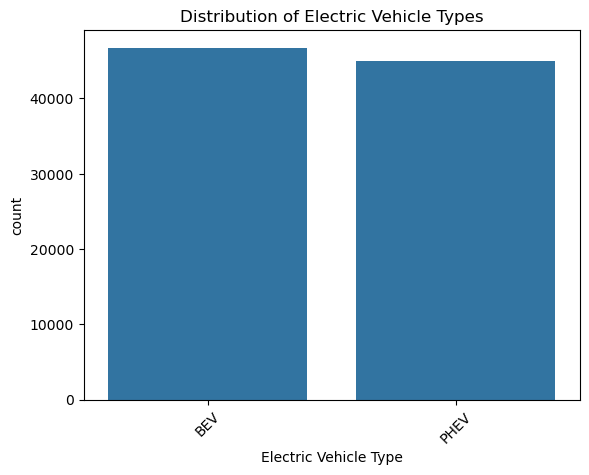

In [37]:
sns.countplot(data=df, x='Electric Vehicle Type', order=df['Electric Vehicle Type'].value_counts().index)
plt.title('Distribution of Electric Vehicle Types')
plt.xticks(rotation=45)
plt.show()

BEV type vehicles still dominate but have a slight lead

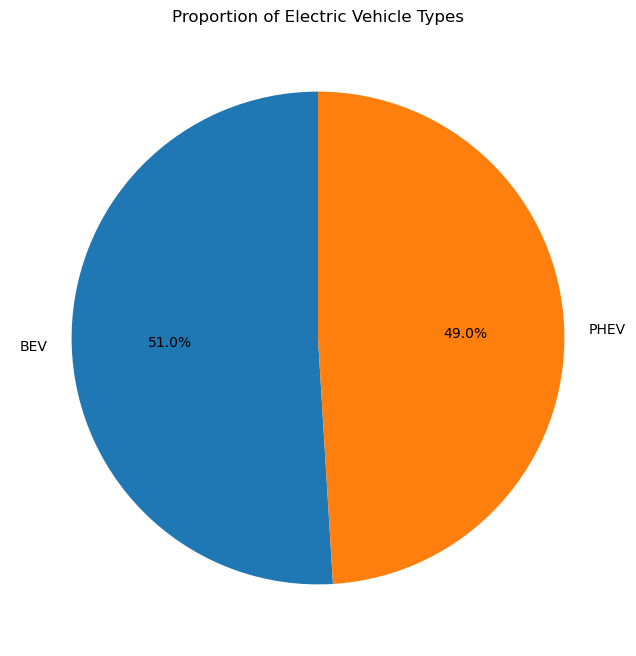

In [38]:
counts = df['Electric Vehicle Type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
)

plt.title('Proportion of Electric Vehicle Types')
plt.show()

The population trend of both vehicle types shows contrasting patterns. Battery Electric Vehicles (BEVs) experienced a sharp rise, reaching their peak between 2018 and 2020, before declining significantly in the following years. In contrast, Plug-in Hybrid Electric Vehicles (PHEVs) demonstrate a consistently steady upward trend from year to year

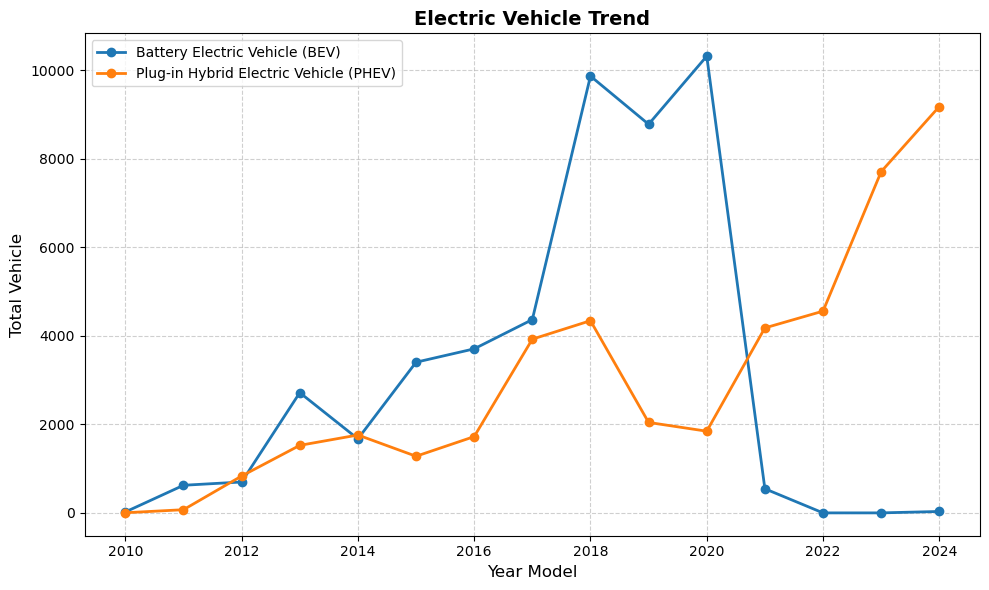

In [ ]:
# Filtering type of electric vehicles
df = df[df["Electric Vehicle Type"].isin(["BEV", "PHEV"])]

# Grouping data to get the count of each type per year
ev_trend = (
    df.groupby(["Model Year", "Electric Vehicle Type"])
    .size()
    .reset_index(name="Count")
)

pivot_data = (
    ev_trend.pivot(index="Model Year", columns="Electric Vehicle Type", values="Count").fillna(0)
)


plt.figure(figsize=(10,6))
plt.plot(pivot_data.index, pivot_data["BEV"], marker='o', linewidth=2, label="Battery Electric Vehicle (BEV)")
plt.plot(pivot_data.index, pivot_data["PHEV"], marker='o', linewidth=2, label="Plug-in Hybrid Electric Vehicle (PHEV)")

# Add title
plt.title("Electric Vehicle Trend", fontsize=14, fontweight='bold')
plt.xlabel("Year Model", fontsize=12)
plt.ylabel("Total Vehicle", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

In [40]:
dfMin = df['Electric Range'].min()
dfMax = df['Electric Range'].max()

print(f'Electric Range Min: {dfMin}')
print(f'Electric Range Max: {dfMax}')

Electric Range Min: 6
Electric Range Max: 337


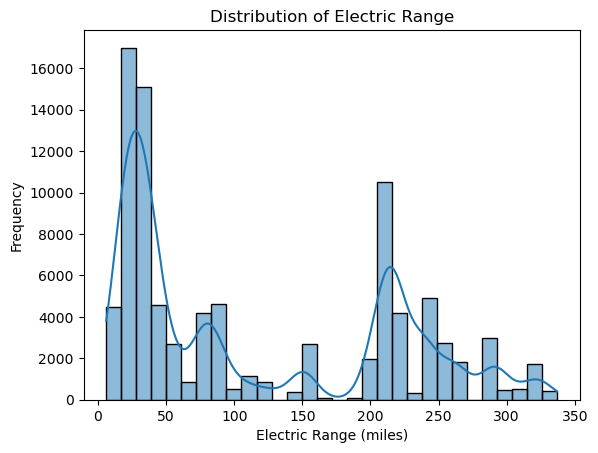

In [41]:
# Plot the distribution of electric range
sns.histplot(df['Electric Range'], bins=30, kde=True)
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Frequency')
plt.show()

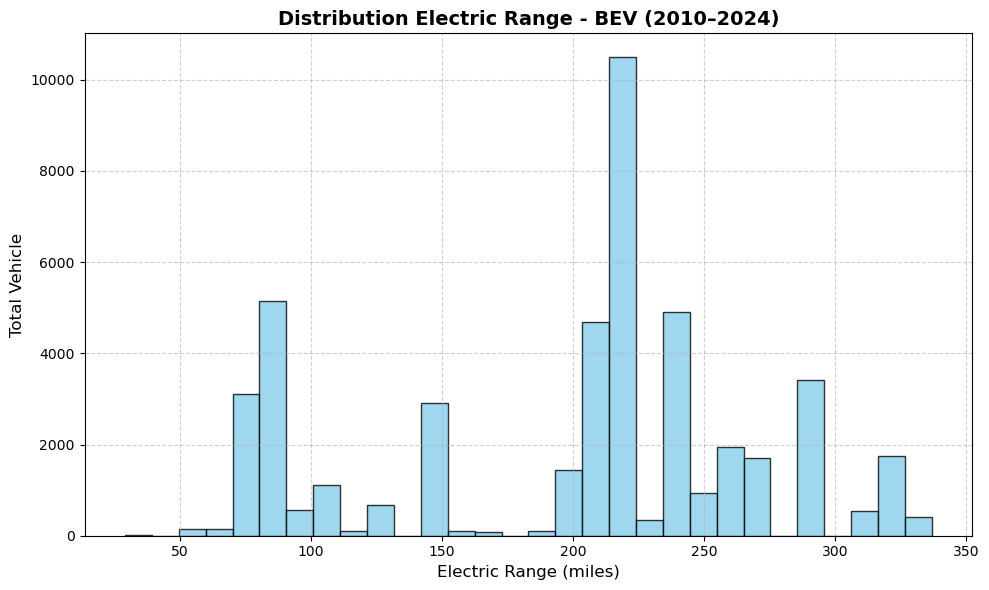

In [42]:
bev = df[df["Electric Vehicle Type"] == "BEV"]

plt.figure(figsize=(10,6))
plt.hist(bev["Electric Range"], bins=30, color="skyblue", edgecolor="black", alpha=0.8)
plt.title("Distribution Electric Range - BEV (2010–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Electric Range (miles)", fontsize=12)
plt.ylabel("Total Vehicle", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [43]:
bev['Electric Range'].mean().round()

np.float64(198.0)

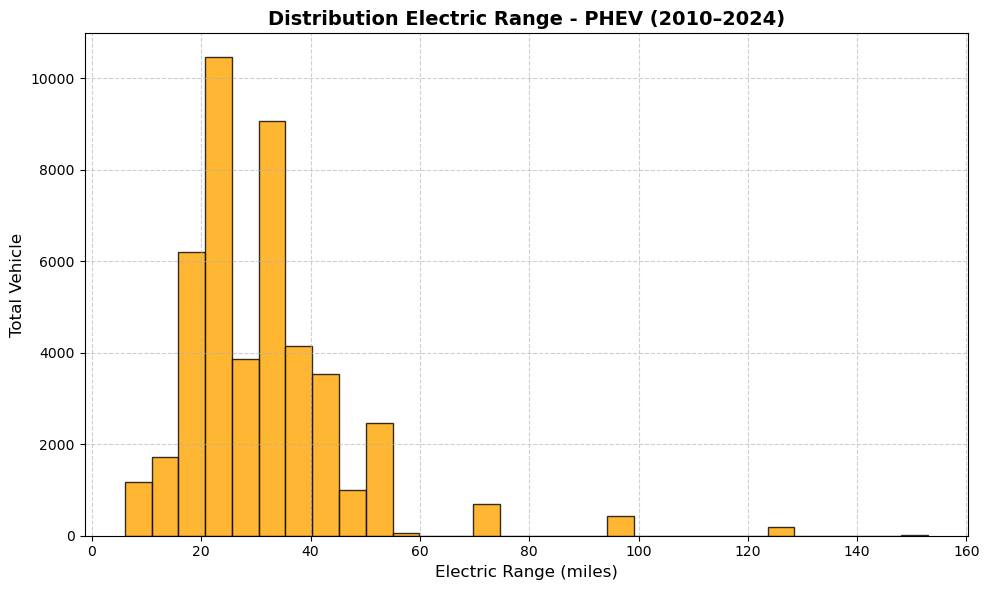

In [44]:
phev = df[df["Electric Vehicle Type"] == "PHEV"]

plt.figure(figsize=(10,6))
plt.hist(phev["Electric Range"], bins=30, color="orange", edgecolor="black", alpha=0.8)
plt.title("Distribution Electric Range - PHEV (2010–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Electric Range (miles)", fontsize=12)
plt.ylabel("Total Vehicle", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [45]:
phev['Electric Range'].median()

30.0

In [46]:
df.groupby('Electric Vehicle Type')['Electric Range'].median().sort_values(ascending=False).round()

Electric Vehicle Type
BEV     215.0
PHEV     30.0
Name: Electric Range, dtype: float64

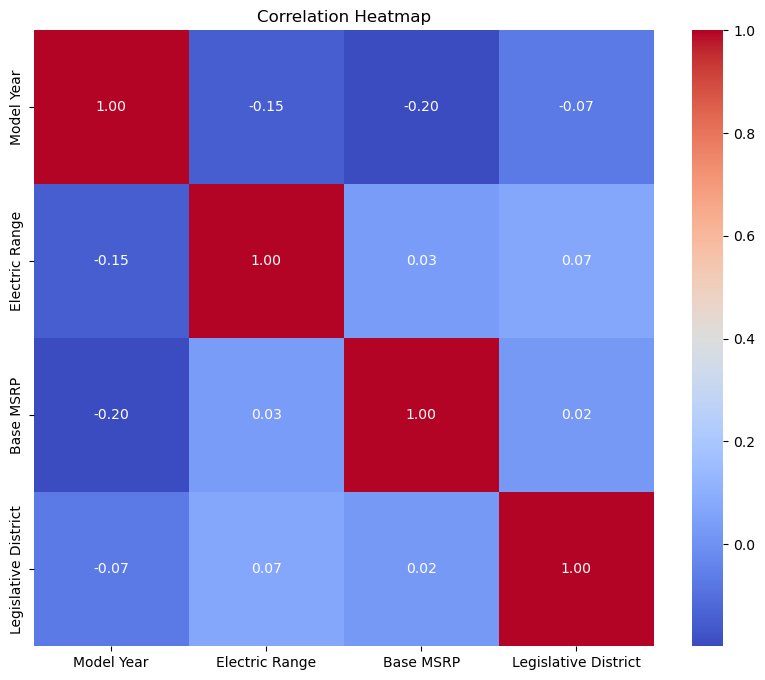

In [47]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

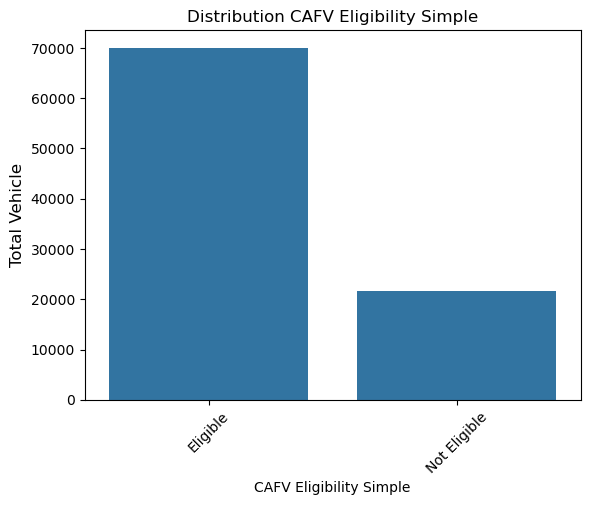

In [48]:
sns.countplot(data=df, x='CAFV Eligibility Simple', order=df['CAFV Eligibility Simple'].value_counts().index)
plt.title('Distribution CAFV Eligibility Simple')
plt.ylabel("Total Vehicle", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [49]:
# Hitung total baris
total_rows = len(df)

# Hitung jumlah baris dengan nilai 0 pada kolom Base MSRP
zero_rows = (df['Base MSRP'] == 0).sum()

# Hitung persentasenya
percent_zero = (zero_rows / total_rows) * 100

print(f"Persentase nilai 0 pada kolom Base MSRP: {percent_zero:.2f}%")


Persentase nilai 0 pada kolom Base MSRP: 96.45%


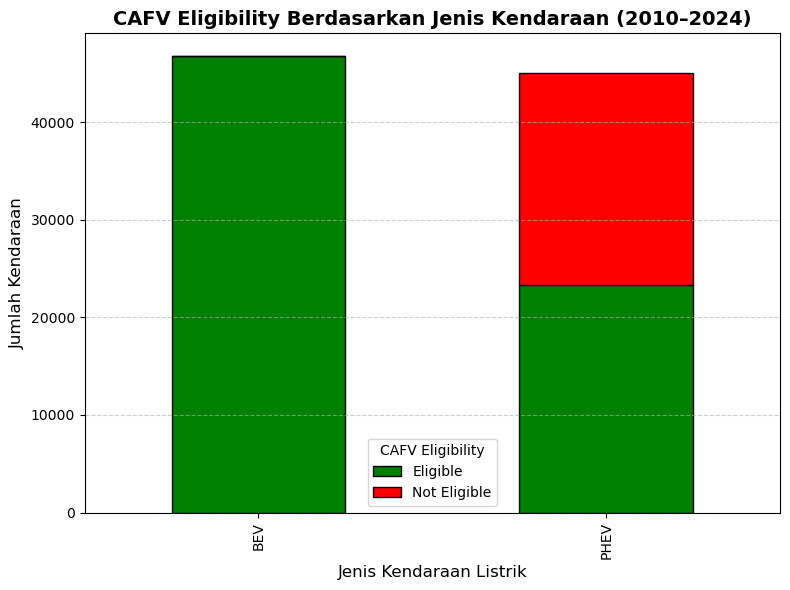

In [50]:
cafv_by_type = (
    df.groupby(["Electric Vehicle Type", "CAFV Eligibility Simple"])
    .size()
    .unstack(fill_value=0)
)

# Plot stacked bar chart
cafv_by_type[["Eligible", "Not Eligible"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["green", "red"],
    edgecolor="black"
)

# Tambahkan judul dan label
plt.title("CAFV Eligibility Berdasarkan Jenis Kendaraan (2010–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Jenis Kendaraan Listrik", fontsize=12)
plt.ylabel("Jumlah Kendaraan", fontsize=12)
plt.legend(title="CAFV Eligibility", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

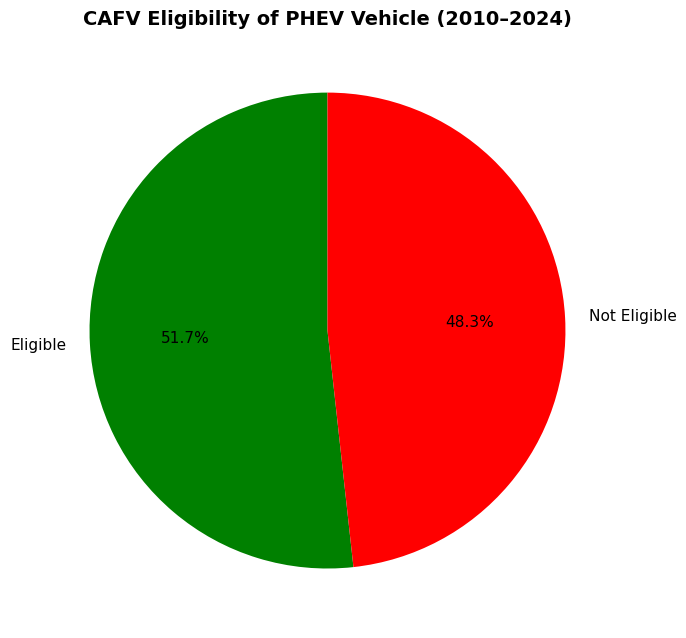

In [51]:
phev = df[df["Electric Vehicle Type"] == "PHEV"]

phevCAFV = phev['CAFV Eligibility Simple'].value_counts()

phev_cafv = phevCAFV.reindex(["Eligible", "Not Eligible"]).fillna(0)

# Plot pie chart
plt.figure(figsize=(7,7))
colors = ["green", "red"]
plt.pie(
    phev_cafv,
    labels=phev_cafv.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11}
)

# Styling
plt.title("CAFV Eligibility of PHEV Vehicle (2010–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

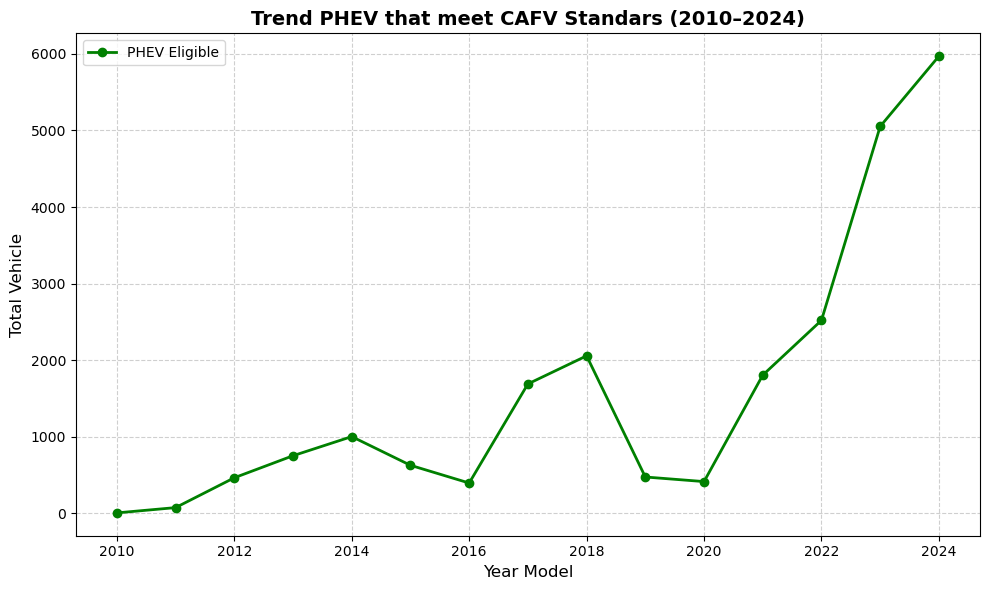

In [52]:
phev_eligible_trend = (
    phev[phev["CAFV Eligibility Simple"] == "Eligible"]
    .groupby("Model Year")
    .size()
    .reset_index(name="Jumlah Eligible")
)

# Plot line chart
plt.figure(figsize=(10,6))
plt.plot(
    phev_eligible_trend["Model Year"],
    phev_eligible_trend["Jumlah Eligible"],
    marker="o",
    color="green",
    linewidth=2,
    label="PHEV Eligible"
)

plt.title("Trend PHEV that meet CAFV Standars (2010–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Year Model", fontsize=12)
plt.ylabel("Total Vehicle", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


# ANALYSIS

EDA, Linear regression